# Generate Arctic region mask on ECCOv4r5 grid

In [1]:
#### data management ####
import numpy as np
import xarray as xr
from xmitgcm import open_mdsdataset
from progressbar import progressbar
#### reprojection ####
from pyproj import CRS, Transformer
#### data plotting ####
import cartopy.crs as ccrs
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
from ecco_v4_py import resample_to_latlon
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [2]:
import warnings
warnings.filterwarnings("ignore")

#### Functions

In [3]:
def comp_dist(lon_ref, lat_ref, lon_comp, lat_comp):
    # Earth radius
    Rt = 6.371e6
    # Compute distance latitude distance to every lon_comp point
    dlat = Rt*np.pi*(lat_comp-lat_ref)/180
    # Compute distance longitude distance to every lon_comp point
    dlon = Rt*np.cos(lat_comp*np.pi/180)*np.pi*(lon_comp-lon_ref)/180
    # Compute distance to the point
    dist = np.sqrt(dlat**2+dlon**2)
    return(dist)

## I. Read data

In [4]:
#### set folders ####
root = "/Volumes/Itsasorantz/"
nsidc_pth = root+"data/sea-ice/"
ecco_pth = root+"data/ECCO/ECCO-Dv5/bin_files/"
out_pth = root+"data/ECCO/ECCOv5/add_files/arctic/"

In [7]:
#### read NSIDC mask data ####
nsidc_ds = xr.open_dataset(nsidc_pth+"NSIDC-SeaIceRegions_EASE2-N12.5km.nc")
#### read ECCO grid data ####
ecco_ds = open_mdsdataset(ecco_pth, ecco_pth+"grid", prefix=' ', iters=12, geometry='llc')

## II. Get NSIDC mask on ECCOv4r5 grid

In [6]:
#### Generate reprojetiom scheme ####
crs_geo = CRS.from_epsg(4326)
crs_ease = CRS.from_epsg(3408)
tsf = Transformer.from_crs(crs_ease, crs_geo, always_xy=True)
#### Get EASE geographic coordinates ####
x,y = np.meshgrid(nsidc_ds.x,nsidc_ds.y)
XN, YN = tsf.transform(x, y)
Rmask = nsidc_ds.sea_ice_region.values

In [7]:
#### Get ECCOv5 coordinates ####
XC = ecco_ds.XC.values
YC = ecco_ds.YC.values
Lmask = ecco_ds.maskC.isel(k=0).values

In [9]:
#### Compute the mask on ECCO grid ####
AOmask = np.zeros(Lmask.shape)
for f in progressbar([2,5,6,7,10]):
    for j in range(AOmask.shape[1]):
        for i in range(AOmask.shape[2]):
            if Lmask[f,j,i] == True:
                dist = comp_dist(XN, YN, XC[f,j,i], YC[f,j,i])
                idm = np.where(dist==np.min(dist))
                AOmask[f,j,i] = Rmask[idm]

## III. Save into a netcdf file

In [10]:
########## Create a xarray ########## 
ds_out = xr.Dataset(data_vars=dict(regions=(["face","j","i"], AOmask), land=(["face","j","i"], Lmask),
                                   XC=(["face","j","i"], XC), YC=(["face","j","i"], YC)),
                    coords=dict(face=ecco_ds.face.values, i=ecco_ds.i.values, j=ecco_ds.j.values))

In [11]:
ch = input("Do you want to save the region dataset created? (y/n)")
fnm = out_pth+"regions.nc"
if ch == 'y':
    ds_out.to_netcdf(fnm, mode='w')

## IV. Plot regions

In [12]:
########## Read generated netcdf ########## 
ds_plt = xr.open_dataset(out_pth+"regions.nc")
ds_plt = ds_plt.rename({'face': 'tile'})
########## params ########## 
cmap = plt.get_cmap('jet', 19)
reg_id = [0,1,2,3,4,5,6,7,8,9,12,13]

In [13]:
########## Select region to plot ########## 
reg1 = ds_plt.regions.where((ds_plt.regions>0)&(ds_plt.regions<=13)&(ds_plt.regions!=10)&(ds_plt.regions!=11))
reg2 = ds_plt.regions.where((ds_plt.regions<=13)&(ds_plt.regions!=10)&(ds_plt.regions!=11))
########## Interpolate for plot ########## 
lon, lat, _, _, reg_ctf = resample_to_latlon(ds_plt.XC, ds_plt.YC, reg1,40,90,.3,-180,180,.3,
                                             mapping_method='nearest_neighbor',radius_of_influence = 112000)
_, _, _, _, reg_ct = resample_to_latlon(ds_plt.XC, ds_plt.YC, reg2,40,90,.3,-180,180,.3,
                                        mapping_method='nearest_neighbor',radius_of_influence = 112000)

In [14]:
##### Mapping parameters #####
pjc = ccrs.NorthPolarStereo(true_scale_latitude=70, central_longitude=-45.0)
parallels = np.arange(60,90,10)
meridians = np.arange(-180,180.,45)
## Circular shape
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

In [67]:
reg_spe = reg_ctf.copy()
#reg_spe[reg_spe!=2] = np.nan
reg_spe[(reg_spe<2)|(reg_spe>7)] = np.nan

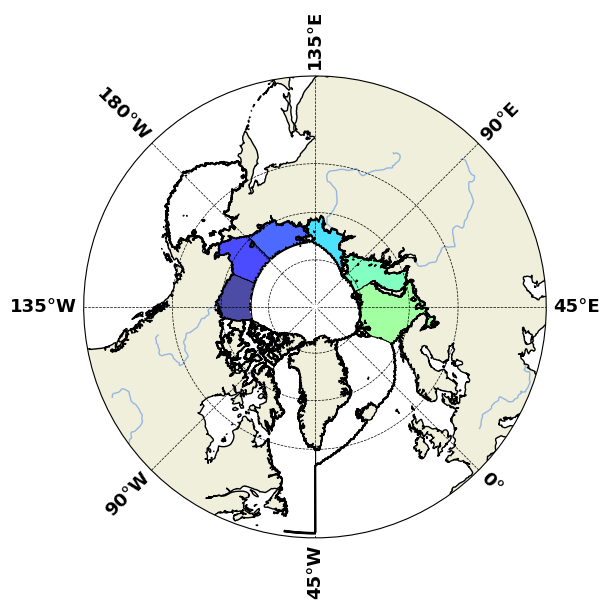

In [68]:
fig = plt.figure(figsize=(6,6))
ax = plt.axes(projection=pjc)
###### PLOT ######
#ax.contourf(lon, lat, reg_ctf, transform=ccrs.PlateCarree(), cmap=cmap, levels=reg_id, alpha=.7, zorder=-77)
ax.contourf(lon, lat, reg_spe, transform=ccrs.PlateCarree(), cmap=cmap, vmax=12, alpha=.7, zorder=-150)
ax.contour(lon, lat, reg_ct, transform=ccrs.PlateCarree(), colors='k', linewidths=.8, levels=reg_id, zorder=-76)
###### PARAMS ######
ax.set_extent([-180, 180, 43, 90], ccrs.PlateCarree())
ax.coastlines(zorder=-74, resolution='50m'); ax.add_feature(cfeature.LAND, zorder=-85); ax.add_feature(cfeature.RIVERS, zorder=-80)
gl = ax.gridlines(crs=ccrs.PlateCarree(), linestyle='--', color='k',linewidth=.5, draw_labels=True,
                  xlocs=meridians, ylocs=parallels, zorder=0)
gl.xformatter = LONGITUDE_FORMATTER; gl.xlabel_style = {'size': 13, 'color': 'k', 'weight': 'bold'}
gl.yformatter = LATITUDE_FORMATTER; gl.ylabel_style = {'size': 0}
ax.set_boundary(circle, transform=ax.transAxes)
#plt.savefig("/Users/bertin/Desktop/Reg.png", transparent=True)
plt.show()

## Plot map of Arctic regions

In [8]:
regions_grid = xr.open_dataset("AO_regions.nc")

In [59]:
# select only regions 1-7
arctic_regions = regions_grid.regions.where(np.logical_and(regions_grid.regions>0,regions_grid.regions<8))

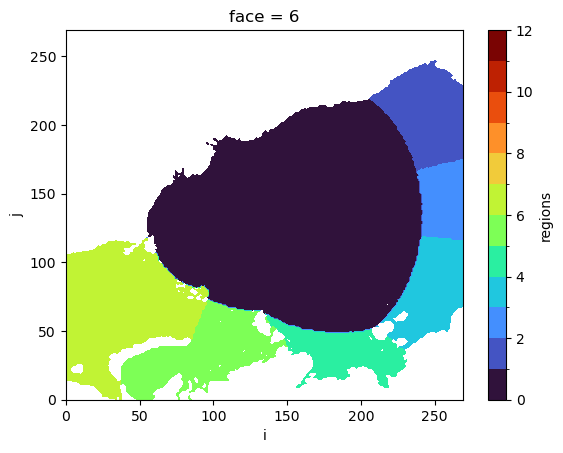

In [63]:
arctic_regions.isel(face=6).plot.contourf(cmap='turbo',levels=np.arange(0,13));

In [41]:
# Interpolate for plot
lon, lat, _, _, reg_ctf = resample_to_latlon(regions_grid.XC, regions_grid.YC, reg1,40,90,.3,-180,180,.3,
                                             mapping_method='nearest_neighbor',radius_of_influence = 112000)
_, _, _, _, reg_ct = resample_to_latlon(regions_grid.XC, regions_grid.YC, reg2,40,90,.3,-180,180,.3,
                                        mapping_method='nearest_neighbor',radius_of_influence = 112000)

In [108]:
# Mapping parameters
pjc = ccrs.NorthPolarStereo(true_scale_latitude=70, central_longitude=-135.0)
parallels = np.arange(60,90,10)
meridians = np.arange(-180,180.,45)

## Circular shape
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

In [110]:
reg_spe = reg_ctf.copy()
#reg_spe[reg_spe!=2] = np.nan
# reg_spe[(reg_spe<2)|(reg_spe>7)] = np.nan
reg_spe[(reg_spe<1)|(reg_spe>7)] = np.nan

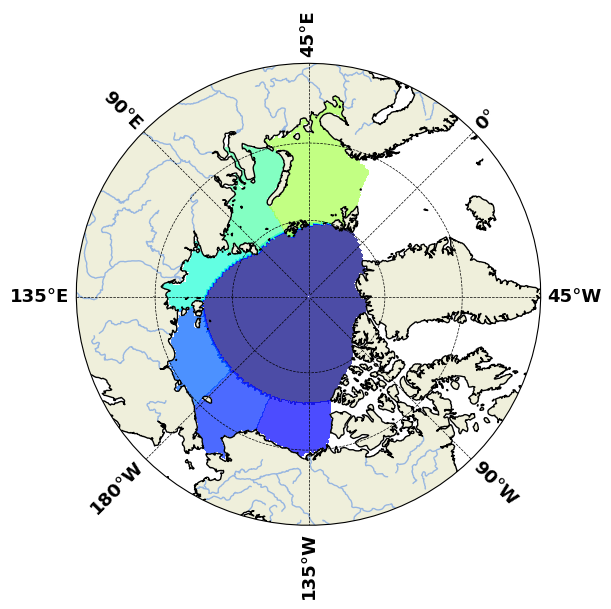

In [120]:
fig = plt.figure(figsize=(6,6))
ax = plt.axes(projection=pjc)

ax.contourf(lon, lat, reg_spe, transform=ccrs.PlateCarree(), cmap=cmap, vmax=12, alpha=.7, zorder=-150)
# ax.contour(lon, lat, reg_spe, transform=ccrs.PlateCarree(), colors='k', linewidths=.8, levels=reg_id, zorder=-76)

# ax.set_extent([-180, 180, 43, 90], ccrs.PlateCarree())
ax.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
ax.coastlines(zorder=-74, resolution='50m'); ax.add_feature(cfeature.LAND, zorder=-85); ax.add_feature(cfeature.RIVERS.with_scale('50m'), zorder=-80)
gl = ax.gridlines(crs=ccrs.PlateCarree(), linestyle='--', color='k',linewidth=.5, draw_labels=True,
                  xlocs=meridians, ylocs=parallels, zorder=0)
gl.xformatter = LONGITUDE_FORMATTER; gl.xlabel_style = {'size': 13, 'color': 'k', 'weight': 'bold'}
gl.yformatter = LATITUDE_FORMATTER; gl.ylabel_style = {'size': 0}
ax.set_boundary(circle, transform=ax.transAxes)

#plt.savefig("/Users/bertin/Desktop/Reg.png", transparent=True)
plt.show()

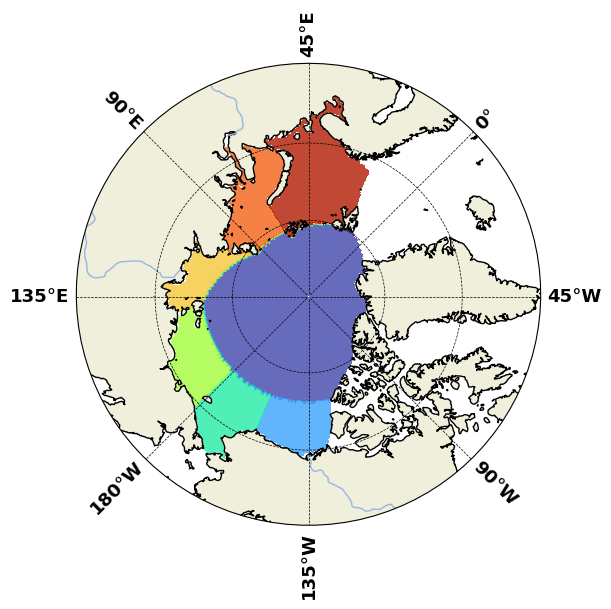

In [158]:
fig = plt.figure(figsize=(6,6))
ax = plt.axes(projection=pjc)

ax.contourf(lon, lat, reg_spe, transform=ccrs.PlateCarree(), levels=[0,1,2,3,4,5,6,7], cmap='turbo', vmax=7, alpha=.8, zorder=-150)
# ax.contour(lon, lat, reg_spe, transform=ccrs.PlateCarree(), colors='k', linewidths=.8, levels=reg_id, zorder=-76)

# ax.set_extent([-180, 180, 43, 90], ccrs.PlateCarree())
ax.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
ax.coastlines(zorder=-74, resolution='50m'); ax.add_feature(cfeature.LAND, zorder=-85); ax.add_feature(cfeature.RIVERS.with_scale('110m'))
gl = ax.gridlines(crs=ccrs.PlateCarree(), linestyle='--', color='k',linewidth=.5, draw_labels=True,
                  xlocs=meridians, ylocs=parallels, zorder=0)
gl.xformatter = LONGITUDE_FORMATTER; gl.xlabel_style = {'size': 13, 'color': 'k', 'weight': 'bold'}
gl.yformatter = LATITUDE_FORMATTER; gl.ylabel_style = {'size': 0}
ax.set_boundary(circle, transform=ax.transAxes)

plt.savefig("arctic_regions.png", transparent=True)
plt.show()